In [1]:
import zipfile

with zipfile.ZipFile('archive.zip', 'r') as zip_ref:
    zip_ref.extractall('ipl_data')

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [2]:
import os

print(os.listdir('ipl_data'))

['matches.csv', 'deliveries.csv']


In [3]:
import pandas as pd

matches = pd.read_csv('ipl_data/matches.csv')
matches.head()

,id,season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3
0,1,2017,Hyderabad,2017-04-05,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Sunrisers Hyderabad,35,0,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal",AY Dandekar,NJ Llong,NaN
1,2,2017,Pune,2017-04-06,Mumbai Indians,Rising Pune Supergiant,Rising Pune Supergiant,field,normal,0,Rising Pune Supergiant,0,7,SPD Smith,Maharashtra Cricket Association Stadium,A Nand Kishore,S Ravi,NaN
2,3,2017,Rajkot,2017-04-07,Gujarat Lions,Kolkata Knight Riders,Kolkata Knight Riders,field,normal,0,Kolkata Knight Riders,0,10,CA Lynn,Saurashtra Cricket Association Stadium,Nitin Menon,CK Nandan,NaN
3,4,2017,Indore,2017-04-08,Rising Pune Supergiant,Kings XI Punjab,Kings XI Punjab,field,normal,0,Kings XI Punjab,0,6,GJ Maxwell,Holkar Cricket Stadium,AK Chaudhary,C Shamshuddin,NaN
4,5,2017,Bangalore,2017-04-08,Royal Challengers Bangalore,Delhi Daredevils,Royal Challengers Bangalore,bat,normal,0,Royal Challengers Bangalore,15,0,KM Jadhav,M Chinnaswamy Stadium,NaN,NaN,NaN


In [5]:
import os
print(os.listdir('ipl_data'))

['matches.csv', 'deliveries.csv']


In [6]:
matches = pd.read_csv('ipl_data/matches.csv')

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [8]:
matches = pd.read_csv("ipl_data/matches.csv")

print(matches.shape)
matches.head()

(636, 18)


,id,season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3
0,1,2017,Hyderabad,2017-04-05,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Sunrisers Hyderabad,35,0,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal",AY Dandekar,NJ Llong,NaN
1,2,2017,Pune,2017-04-06,Mumbai Indians,Rising Pune Supergiant,Rising Pune Supergiant,field,normal,0,Rising Pune Supergiant,0,7,SPD Smith,Maharashtra Cricket Association Stadium,A Nand Kishore,S Ravi,NaN
2,3,2017,Rajkot,2017-04-07,Gujarat Lions,Kolkata Knight Riders,Kolkata Knight Riders,field,normal,0,Kolkata Knight Riders,0,10,CA Lynn,Saurashtra Cricket Association Stadium,Nitin Menon,CK Nandan,NaN
3,4,2017,Indore,2017-04-08,Rising Pune Supergiant,Kings XI Punjab,Kings XI Punjab,field,normal,0,Kings XI Punjab,0,6,GJ Maxwell,Holkar Cricket Stadium,AK Chaudhary,C Shamshuddin,NaN
4,5,2017,Bangalore,2017-04-08,Royal Challengers Bangalore,Delhi Daredevils,Royal Challengers Bangalore,bat,normal,0,Royal Challengers Bangalore,15,0,KM Jadhav,M Chinnaswamy Stadium,NaN,NaN,NaN


In [9]:
matches.isnull().sum()

,0
id,0
season,0
city,7
date,0
team1,0
team2,0
toss_winner,0
toss_decision,0
result,0
dl_applied,0


In [10]:
matches = matches.drop([
    'umpire1',
    'umpire2',
    'umpire3',
    'method'
], axis=1, errors='ignore')

matches.fillna("Unknown", inplace=True)

matches = matches[matches['winner'] != "Unknown"]

print(matches.shape)

(633, 15)


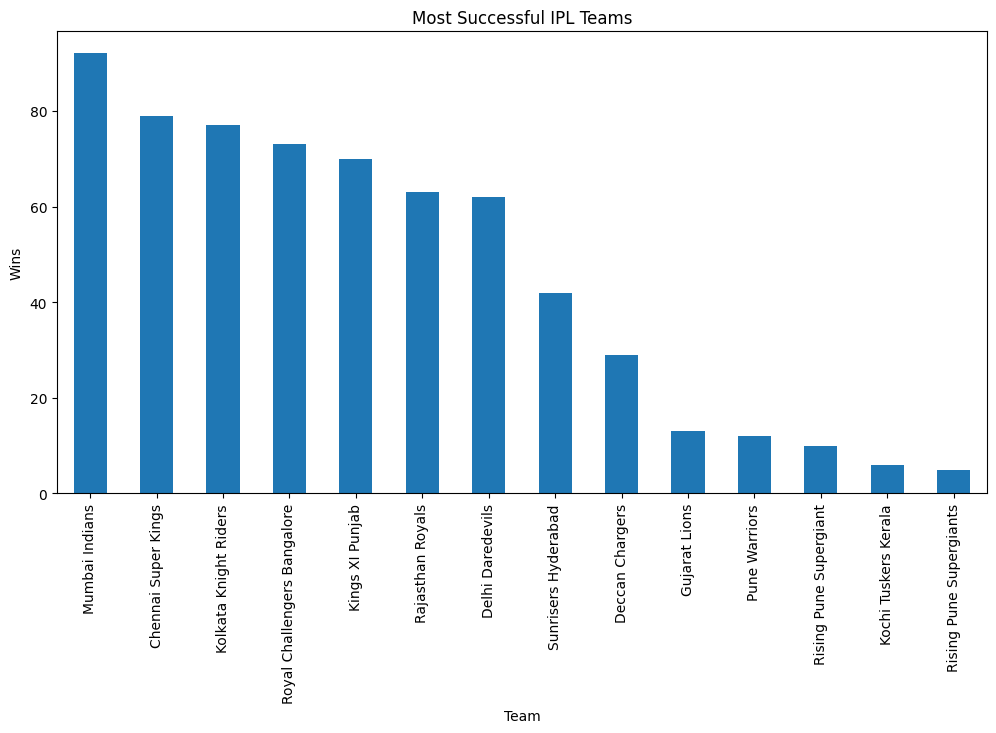

In [11]:
plt.figure(figsize=(12,6))
matches['winner'].value_counts().plot(kind='bar')
plt.title("Most Successful IPL Teams")
plt.xlabel("Team")
plt.ylabel("Wins")
plt.xticks(rotation=90)
plt.show()

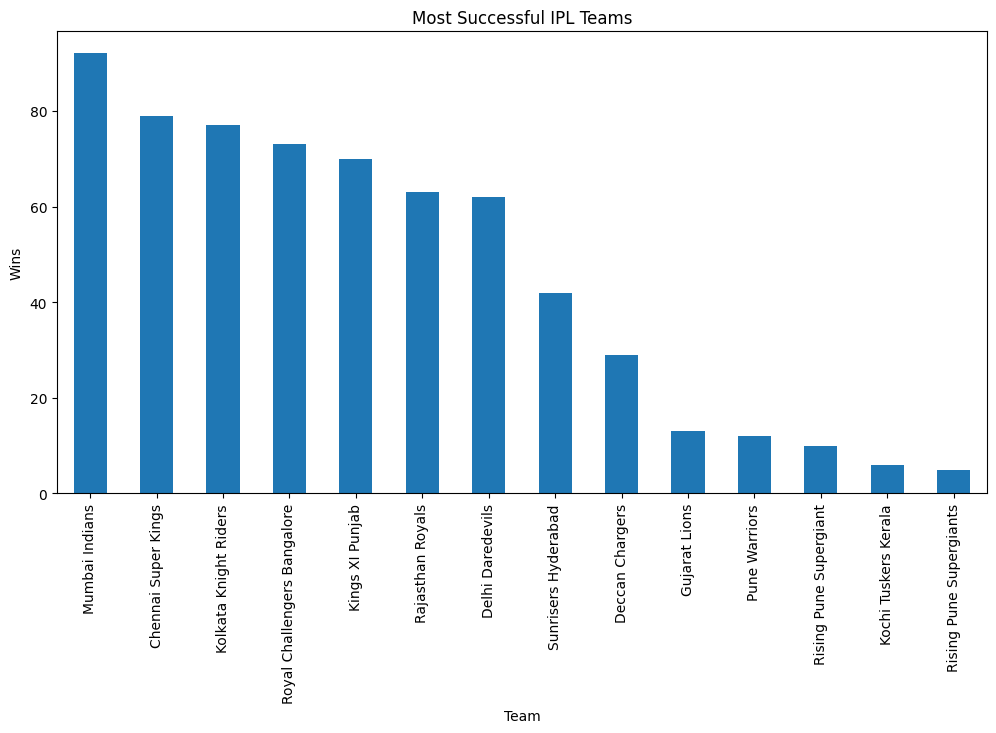

In [12]:
plt.figure(figsize=(12,6))
matches['winner'].value_counts().plot(kind='bar')
plt.title("Most Successful IPL Teams")
plt.xlabel("Team")
plt.ylabel("Wins")
plt.xticks(rotation=90)
plt.show()

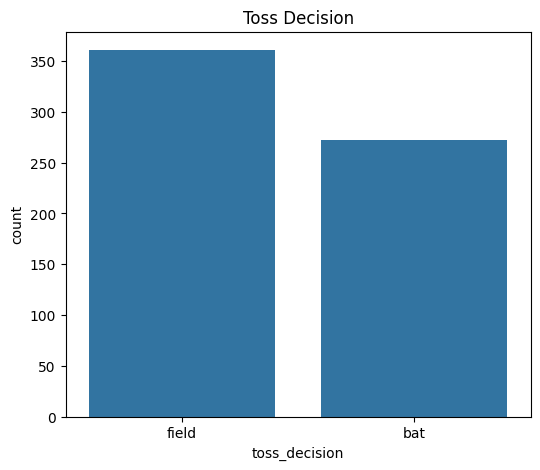

In [13]:
plt.figure(figsize=(6,5))
sns.countplot(data=matches, x='toss_decision')
plt.title("Toss Decision")
plt.show()

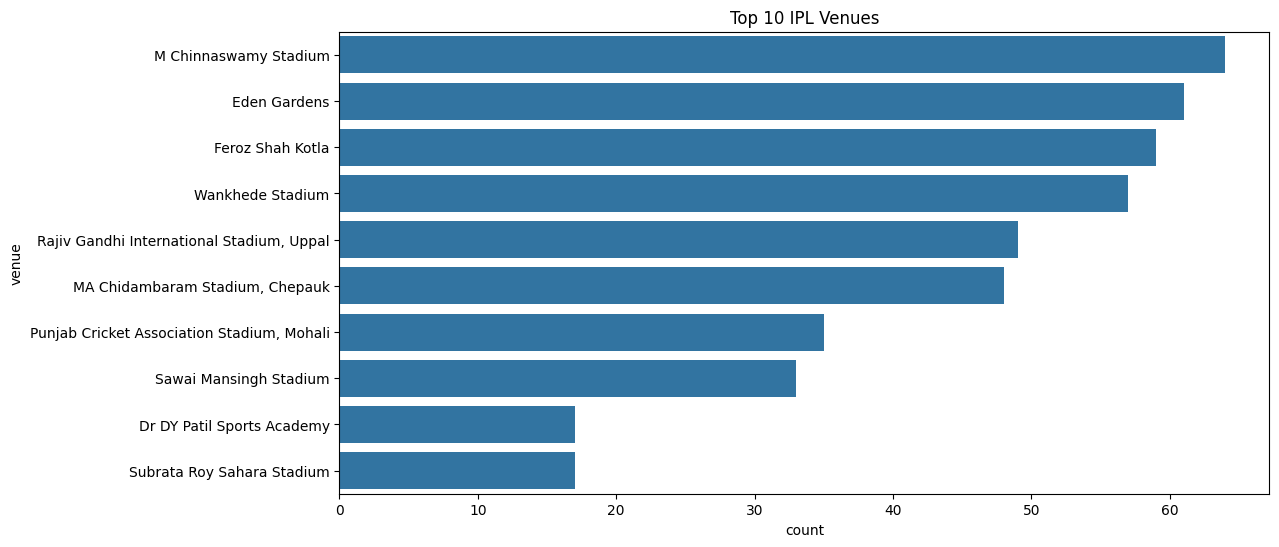

In [14]:
plt.figure(figsize=(12,6))
sns.countplot(
    y='venue',
    data=matches,
    order=matches['venue'].value_counts().head(10).index
)
plt.title("Top 10 IPL Venues")
plt.show()

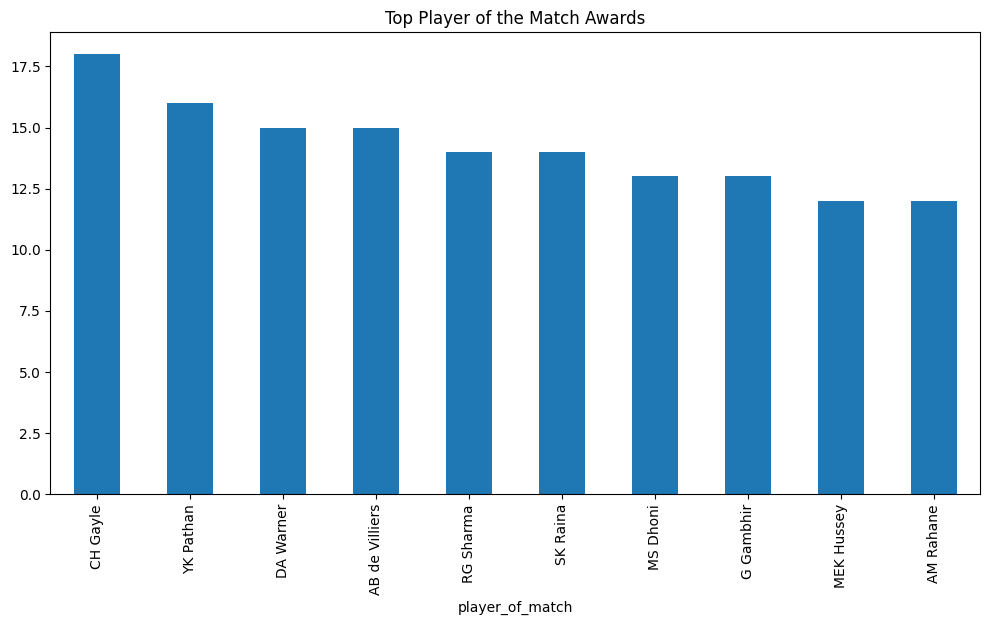

In [15]:
plt.figure(figsize=(12,6))
matches['player_of_match'].value_counts().head(10).plot(kind='bar')
plt.title("Top Player of the Match Awards")
plt.show()

In [16]:
features = [
    'team1',
    'team2',
    'toss_winner',
    'toss_decision',
    'venue',
    'city'
]

target = 'winner'

data = matches[features + [target]].copy()

In [17]:
encoders = {}

for col in data.columns:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col].astype(str))
    encoders[col] = le

In [18]:
X = data.drop('winner', axis=1)
y = data['winner']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [19]:
model = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=300, random_state=42)

In [20]:
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

print(classification_report(y_test, y_pred))

Accuracy: 0.5354330708661418
              precision    recall  f1-score   support

           0       0.52      0.50      0.51        22
           1       0.40      0.33      0.36         6
           2       0.57      0.44      0.50         9
           3       1.00      0.67      0.80         3
           4       0.67      0.50      0.57        16
           5       0.00      0.00      0.00         1
           6       0.64      0.74      0.68        19
           7       0.39      0.44      0.41        16
           8       0.50      0.50      0.50         2
           9       0.27      0.38      0.32         8
          10       1.00      0.33      0.50         3
          12       0.64      0.56      0.60        16
          13       0.55      1.00      0.71         6

    accuracy                           0.54       127
   macro avg       0.55      0.49      0.50       127
weighted avg       0.56      0.54      0.53       127



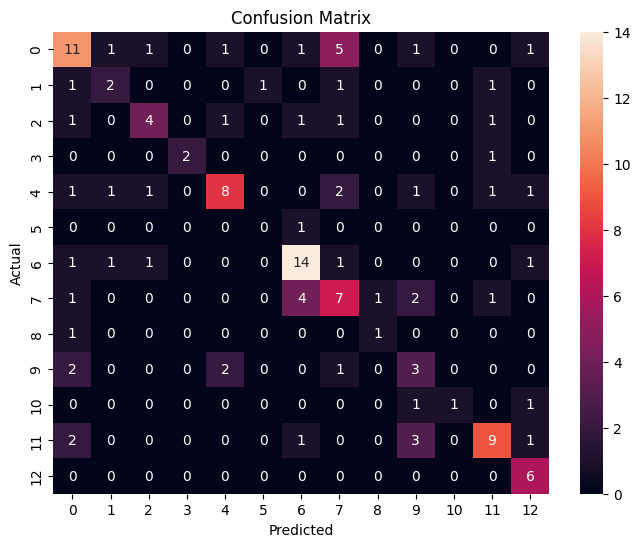

In [21]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

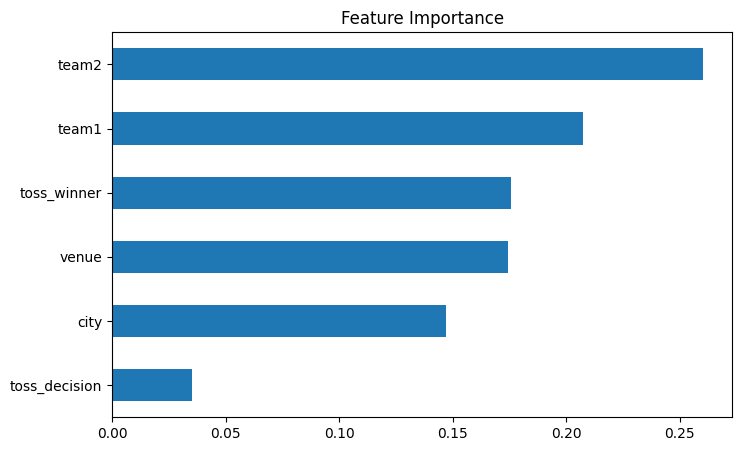

In [22]:
importance = pd.Series(
    model.feature_importances_,
    index=X.columns
)

importance.sort_values().plot(
    kind='barh',
    figsize=(8,5)
)

plt.title("Feature Importance")
plt.show()

In [23]:
sample = pd.DataFrame({
    'team1':['Mumbai Indians'],
    'team2':['Chennai Super Kings'],
    'toss_winner':['Mumbai Indians'],
    'toss_decision':['bat'],
    'venue':['Wankhede Stadium'],
    'city':['Mumbai']
})

for col in sample.columns:
    sample[col] = encoders[col].transform(sample[col])

prediction = model.predict(sample)

print("Predicted Winner:",
      encoders['winner'].inverse_transform(prediction)[0])

Predicted Winner: Mumbai Indians
